In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import functions
from model_eqns_scenario_2 import malaria_model
from parameter_values_scenario import params

In [3]:
#Read data
Macapa_data_2019 = pd.read_csv('./data/Macapa_data_2019.csv')
Manaus_data_2019 = pd.read_csv('./data/Manaus_data_2019.csv')

In [4]:
Temperature_urban = Macapa_data_2019['Temp.Comp.Media']
Temperature_rural = Manaus_data_2019['Temp.Comp.Media']

Rainfall_urban = Macapa_data_2019['Precipitacao']
Rainfall_rural = Manaus_data_2019['Precipitacao']

In [5]:
# DAYS = 365
# t = np.arange(DAYS)
# Defining the time range
initial_time = 1
final_time = len(Temperature_urban)  
tempo = np.arange(initial_time, final_time + 1)  

#Defining the initial condition Macapa

Nh_U= 5.03327e5
Nm_U = Nh_U*params['m_U']
init_U = 306 # Model simulation at the end of 2018


#Defining the initial condition Manaus
Nh_R = 2.2e6 
Nm_R = Nh_R*params['m_R']
init_R = 5000 # model simulation at the end of 2018
inicial = {'tempo':1, 'Sh_UU' : 1-init_U/Nh_U, 'Sh_UR' : 0, 'Ih_UU' : init_U/Nh_U, 'Ih_UR' : 0, 'L_UU' : 0, 'L_UR' : 0, 'P_UU' : 0, 'P_UR' : 0, 'Sm_U' : params['m_U'], 
             'Im_U' : 0, 'Cases_U' : 0, 'Nm_U' : Nm_U, 'Nh_U' : 1,   'Sh_RR' : 1-init_R/Nh_R, 'Sh_RU' :0, 'Ih_RR' : init_R/Nh_R, 'Ih_RU' : 0,  'L_RR' : 0, 'L_RU' : 0,
            'P_RR' : 0, 'P_RU' : 0, 'Sm_R' : params['m_R'], 'Im_R' : 0, 'Cases_R' : 0 , 'Nm_R' : Nm_R , 'Nh_R' : 1}

#Creating the results matrix
df_sim = pd.DataFrame({"tempo": tempo})
vars = ["Sh_UU", "Sh_UR", "Ih_UU", "Ih_UR", "L_UU", "L_UR", "P_UU", "P_UR", "Sm_U", "Im_U", "Cases_U", "Nm_U",  "Nh_U", 
        "Sh_RR", "Sh_RU", "Ih_RR", "Ih_RU", "L_RR", "L_RU", "P_RR", "P_RU", "Sm_R", "Im_R",  "Cases_R" , "Nm_R", "Nh_R"]
df_sim[vars] = np.nan # Initialize with NaN values
df_sim.loc[0] = inicial # Set the first row with initial conditions

In [6]:
clim = {"T_u": Temperature_urban.copy(), "T_r": Temperature_rural.copy(), "R_u": Rainfall_urban.copy(), "R_r": Rainfall_rural.copy()}
m_RU1_base = 0.003  # per day baseline rural->urban outflow
m_UR1_base = 0.003  # per day baseline rural->urban outflow

tau_base = 10.0
m_RU2_base = 1.0 / tau_base
m_UR2_base = 1.0 / tau_base

m_RU1_t = np.full(final_time, m_RU1_base)
m_UR1_t = np.full(final_time, m_UR1_base)
m_RU2 = m_RU2_base
m_UR2 = m_UR2_base
mob = {"m_UR1_t": m_UR1_t, "m_UR2": m_UR2, "m_RU1_t": m_RU1_t, "m_RU2": m_RU2}

In [7]:
# Build intervention scenarios
scenario_params = params.copy()
intervention_scenarios = {
    "scenario 0": {},
    "scenario 1": {"c_u2": 0.9}, # reduction of biting rate for only urban visitors
    "scenario 2": {"c_u2_1": 0.9}, # reduction of biting rate for only rural visitors
    "scenario 3": {"c_u1": 0.9, "c_u3": 1}, # Urban Insectcide treated nets (ITNS) usage- decrese biting rate and increase death rate
    "scenario 4": {"c_r1": 0.9, "c_r2": 1}, # Rrban Insectcide treated nets (ITNS) usage- decrese biting rate and increase death rate
  
    "scenario 5": {"c_r3": 0.9}, #Larvae source management- decrease in birth rate of mosquitos in rural
    "scenario 6": {"c_u5": 0.9}, #Larvae source management- decrease in birth rate of mosquitos in urban

    "scenario 7": {"c_r4": 1.1}, # Increase treatment coverage in rural
    "scenario 8": {"c_u4": 1.1}, # Increase treatment coverage in urban
    
}

In [8]:
scenario_names = {
    "scenario 0": 'Status quo (no intervention)',
    "scenario 1": 'ITNS-urban vistors only',
    "scenario 2": 'ITNS-rural vistors only',
    "scenario 3": 'ITNS-urban only', 
    "scenario 4": 'ITNS-rural only',

    "scenario 5": 'Larvae source management-rural only',
    "scenario 6": 'Larvae source management-urban only',

    "scenario 7": 'Increase treatment coverage- rural only',
     "scenario 8": 'Increase treatment coverage- urban only'
    
}

In [9]:
# loop through scenarios
results = {}
for name, changes in intervention_scenarios.items():
    current_params = scenario_params.copy()   # start from baseline
    current_params.update(changes)            # apply scenario changes
    
    solution = malaria_model(df_sim, clim, mob, current_params) # solve the model per each scenario
    
    Urban_model_cases = (solution['Cases_U']*Nh_U).cumsum()
    Rural_model_cases = (solution['Cases_R']*Nh_R).cumsum()
    
    urban_infection_size = Urban_model_cases.iloc[-1]
    rural_infection_size = Rural_model_cases.iloc[-1]

    results[name] = {
        'urban cumulative cases': Urban_model_cases,
        'Rural cumulative cases': Rural_model_cases,
        'Urbn final size': urban_infection_size,
        'Rural final size': rural_infection_size
    }

all_results = pd.DataFrame(results)

In [10]:
#Replace scenario names with descriptive labels
df = all_results.T.rename(index=scenario_names)

# --- Urban table ---
urban_table = pd.DataFrame()
urban_table["Urban final size"] = df["Urbn final size"]

baseline_urban = urban_table.loc["Status quo (no intervention)", "Urban final size"]

urban_table["Change"] = baseline_urban - urban_table["Urban final size"]
urban_table["Change (%)"] = (
    (baseline_urban - urban_table["Urban final size"]) / baseline_urban * 100
)

# --- Rural table ---
rural_table = pd.DataFrame()
rural_table["Rural final size"] = df["Rural final size"]

baseline_rural = rural_table.loc["Status quo (no intervention)", "Rural final size"]

rural_table["Change"] = baseline_rural - rural_table["Rural final size"]
rural_table["Change (%)"] = (
    (baseline_rural - rural_table["Rural final size"]) / baseline_rural * 100
)

# Ensure numeric
urban_table = urban_table.apply(pd.to_numeric, errors="coerce")
rural_table = rural_table.apply(pd.to_numeric, errors="coerce")

# Now round works
urban_table = urban_table.round(2)
rural_table = rural_table.round(2)

display("Urban results:", urban_table)
display("Rural results:", rural_table)

'Urban results:'

,Urban final size,Change,Change (%)
Status quo (no intervention),5493.52,0.00,0.00
ITNS-urban vistors only,5485.48,8.04,0.15
ITNS-rural vistors only,5389.70,103.82,1.89
ITNS-urban only,3330.61,2162.91,39.37
ITNS-rural only,4616.82,876.70,15.96
Larvae source management-rural only,4988.18,505.34,9.20
Larvae source management-urban only,4216.02,1277.50,23.25
Increase treatment coverage- rural only,5449.99,43.53,0.79
Increase treatment coverage- urban only,5471.01,22.51,0.41


'Rural results:'

,Rural final size,Change,Change (%)
Status quo (no intervention),57918.03,0.00,0.00
ITNS-urban vistors only,57780.92,137.11,0.24
ITNS-rural vistors only,57808.72,109.31,0.19
ITNS-urban only,57150.13,767.90,1.33
ITNS-rural only,32265.32,25652.71,44.29
Larvae source management-rural only,42685.28,15232.76,26.30
Larvae source management-urban only,57481.48,436.55,0.75
Increase treatment coverage- rural only,56621.36,1296.67,2.24
Increase treatment coverage- urban only,57909.44,8.59,0.01


In [11]:
# combined = pd.concat({"Urban": urban_table, "Rural": rural_table}, axis=1)
# combined.to_excel("scenario_results.xlsx", sheet_name="Summary")

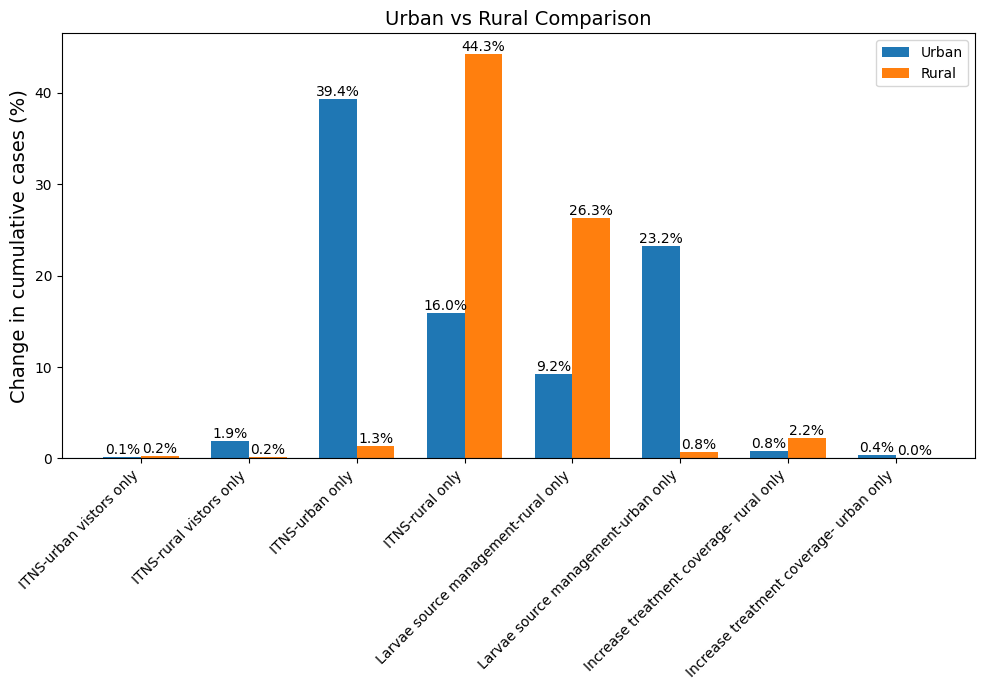

In [12]:

# --- Prepare data (same filtering as before) ---
exclude = ["Status quo (no intervention)"]

urban_plot = urban_table["Change (%)"].reset_index()
urban_plot.columns = ["Scenario", "Urban"]

rural_plot = rural_table["Change (%)"].reset_index()
rural_plot.columns = ["Scenario", "Rural"]

# Merge urban and rural
df_plot = pd.merge(urban_plot, rural_plot, on="Scenario")

# Apply exclusion
df_plot = df_plot[~df_plot["Scenario"].isin(exclude)]

# --- Plot ---
x = np.arange(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 7))

bars1 = ax.bar(x - width/2, df_plot["Urban"], width, label="Urban")
bars2 = ax.bar(x + width/2, df_plot["Rural"], width, label="Rural")

# Labels
ax.set_ylabel("Change in cumulative cases (%)", fontsize=14)
ax.set_title("Urban vs Rural Comparison", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(df_plot["Scenario"], rotation=45, ha="right")

# Reference line at zero (important!)
ax.axhline(0, linewidth=0.8)

# Annotate values
for i, val in enumerate(df_plot["Urban"]):
    ax.text(i - width/2, val, f"{val:.1f}%", ha="center", va="bottom")

for i, val in enumerate(df_plot["Rural"]):
    ax.text(i + width/2, val, f"{val:.1f}%", ha="center", va="bottom")

ax.legend()

plt.tight_layout()
plt.savefig("Fig_intervention_scenario.pdf", dpi = 300, bbox_inches='tight')
plt.show()